In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'./final_df.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      64104 non-null  int64  
 1   order_number    64104 non-null  str    
 2   order_date      64104 non-null  str    
 3   customer_name   64104 non-null  str    
 4   channel         64104 non-null  str    
 5   product_name    64104 non-null  str    
 6   order_quantity  64104 non-null  int64  
 7   unit_price      64104 non-null  float64
 8   revenue         64104 non-null  float64
 9   cost            64104 non-null  float64
 10  state_code      64104 non-null  str    
 11  county          64104 non-null  str    
 12  state_name      64104 non-null  str    
 13  region name     64104 non-null  str    
 14  lat             64104 non-null  float64
 15  budget          39 non-null     float64
dtypes: float64(5), int64(2), str(9)
memory usage: 13.3 MB


In [3]:
df.columns

Index(['Unnamed: 0', 'order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'order_quantity', 'unit_price', 'revenue', 'cost',
       'state_code', 'county', 'state_name', 'region name', 'lat', 'budget'],
      dtype='str')

## Sales & Cost Columns — Quick Reference

These four columns describe the relationship between **how many products were sold, the selling price, the cost of the product, and the total cost**.

| Column           | Meaning                                     | Example | Formula                      |
| ---------------- | ------------------------------------------- | ------: | ---------------------------- |
| `order_quantity` | Number of units/products sold in the order  |    `10` | —                            |
| `unit_price`     | Selling price of **1 unit** to the customer |  `₹100` | —                            |
| `unit_cost`      | Business cost of **1 unit**                 |   `₹60` | —                            |
| `total_cost`     | Total cost for all units in the order       |  `₹600` | `order_quantity × unit_cost` |

## Example

Suppose a customer orders **10 units**:

```text
order_quantity = 10
unit_price     = ₹100
unit_cost      = ₹60
```

### Revenue

Revenue is the total amount received from the customer:

```text
Revenue = order_quantity × unit_price

        = 10 × ₹100

        = ₹1,000
```

### Total Cost

Total cost is the total amount the business spends on those 10 units:

```text
Total Cost = order_quantity × unit_cost

           = 10 × ₹60

           = ₹600
```

### Profit

Profit is what remains after subtracting the total cost from revenue:

```text
Profit = Revenue − Total Cost

       = ₹1,000 − ₹600

       = ₹400
```

## Easy way to remember

Think of it like this:

```text
                 1 UNIT
                   │
        ┌──────────┴──────────┐
        │                     │
   Unit Price              Unit Cost
   ₹100                    ₹60
   │                         │
   │                         │
   └────── × Quantity ───────┘
              │
              ▼
        ┌─────────────┐
        │             │
      Revenue      Total Cost
       ₹1,000         ₹600
        │               │
        └───────┬───────┘
                ▼
             Profit
              ₹400
```

### Pandas formulas

```python
# Revenue
df['revenue'] = df['order_quantity'] * df['unit_price']

# Total Cost
df['total_cost'] = df['order_quantity'] * df['unit_cost']

# Profit
df['profit'] = df['revenue'] - df['total_cost']
```

> **Important:** If your dataset has a column named `cost` instead of `unit_cost`, first check whether `cost` represents the **cost per unit** or the **total cost for the order**. Don't automatically multiply it by `order_quantity`.


In [4]:
df.iloc[0:6, 6:10]

,order_quantity,unit_price,revenue,cost
0,6,2499.1,14994.6,1824.343
1,11,2351.7,25868.7,1269.918
2,6,978.2,5869.2,684.740
3,7,2338.3,16368.1,1028.852
4,8,2291.4,18331.2,1260.270
5,11,5219.3,57412.3,4332.019


In [5]:

df = df.rename(columns={
    'cost': 'unit_cost'
})

# Total Cost
df['total_cost'] = df['order_quantity'] * df['unit_cost']

# Profit
df['profit'] = df['revenue'] - df['total_cost']

In [6]:
# Profit Margin Percentage%
df['profit_margit_%'] = (df['profit']/df['revenue'])*100

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       64104 non-null  int64  
 1   order_number     64104 non-null  str    
 2   order_date       64104 non-null  str    
 3   customer_name    64104 non-null  str    
 4   channel          64104 non-null  str    
 5   product_name     64104 non-null  str    
 6   order_quantity   64104 non-null  int64  
 7   unit_price       64104 non-null  float64
 8   revenue          64104 non-null  float64
 9   unit_cost        64104 non-null  float64
 10  state_code       64104 non-null  str    
 11  county           64104 non-null  str    
 12  state_name       64104 non-null  str    
 13  region name      64104 non-null  str    
 14  lat              64104 non-null  float64
 15  budget           39 non-null     float64
 16  total_cost       64104 non-null  float64
 17  profit           64104 

In [8]:
df.iloc[0:6, [1,5,6,7,8,9,16,17,18]]

,order_number,product_name,order_quantity,unit_price,revenue,unit_cost,total_cost,profit,profit_margit_%
0,SO - 000225,Product 27,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0
1,SO - 0003378,Product 20,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0
2,SO - 0005126,Product 26,6,978.2,5869.2,684.740,4108.440,1760.760,30.0
3,SO - 0005614,Product 7,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0
4,SO - 0005781,Product 8,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0
5,SO - 0010394,Product 23,11,5219.3,57412.3,4332.019,47652.209,9760.091,17.0


### EDA

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       64104 non-null  int64  
 1   order_number     64104 non-null  str    
 2   order_date       64104 non-null  str    
 3   customer_name    64104 non-null  str    
 4   channel          64104 non-null  str    
 5   product_name     64104 non-null  str    
 6   order_quantity   64104 non-null  int64  
 7   unit_price       64104 non-null  float64
 8   revenue          64104 non-null  float64
 9   unit_cost        64104 non-null  float64
 10  state_code       64104 non-null  str    
 11  county           64104 non-null  str    
 12  state_name       64104 non-null  str    
 13  region name      64104 non-null  str    
 14  lat              64104 non-null  float64
 15  budget           39 non-null     float64
 16  total_cost       64104 non-null  float64
 17  profit           64104 

#### Line chart of Monthly Sales

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [11]:
df['order_date'].dt.to_period("M")

0        2014-01
1        2014-01
2        2014-01
3        2014-01
4        2014-01
          ...   
64099    2018-02
64100    2018-02
64101    2018-02
64102    2018-02
64103    2018-02
Name: order_date, Length: 64104, dtype: period[M]

In [12]:
df['order_month'] = df['order_date'].dt.to_period("M")

In [13]:
monthly_sales = df.groupby('order_month')['revenue'].sum()
monthly_sales

order_month
2014-01    25020272.3
2014-02    23882719.5
2014-03    23709035.4
2014-04    24853382.0
2014-05    25662165.8
2014-06    23818794.8
2014-07    23491988.9
2014-08    25408229.1
2014-09    25459497.5
2014-10    24259835.7
2014-11    26268221.0
2014-12    25686587.3
2015-01    25525914.6
2015-02    23027431.0
2015-03    24360945.4
2015-04    23744217.1
2015-05    24995904.4
2015-06    24528391.8
2015-07    24808203.9
2015-08    26155634.2
2015-09    24662586.1
2015-10    25466197.5
2015-11    25573136.2
2015-12    25562148.2
2016-01    24862829.0
2016-02    23151247.0
2016-03    26420512.0
2016-04    23179165.9
2016-05    25265324.8
2016-06    24804170.5
2016-07    24814997.7
2016-08    25082099.9
2016-09    24551560.4
2016-10    25896129.8
2016-11    25078997.8
2016-12    24976635.2
2017-01    24017201.9
2017-02    21241586.2
2017-03    26123159.3
2017-04    23447990.0
2017-05    26348721.5
2017-06    23761335.6
2017-07    24070011.3
2017-08    25301062.6
2017-09    24758657.

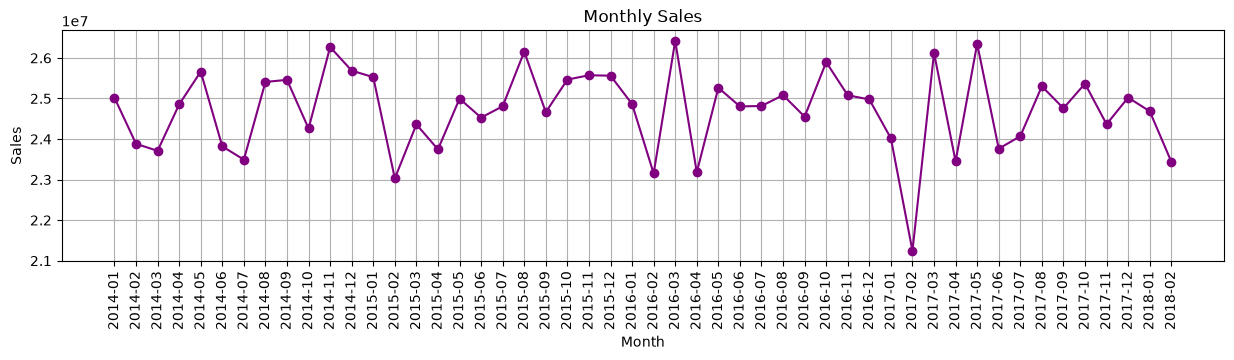

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
plt.plot(
    monthly_sales.index.astype(str), 
    monthly_sales.values,
    color='purple', 
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Note**: *You can notice that in year 2018 has only 2 months i.e. Jan and Feb*

In [15]:
monthly_sales[monthly_sales.min() == monthly_sales]

order_month
2017-02    21241586.2
Freq: M, Name: revenue, dtype: float64

In [16]:
monthly_sales[monthly_sales.max() == monthly_sales]

order_month
2016-03    26420512.0
Freq: M, Name: revenue, dtype: float64

#### Line chart of Overall Monthly Sales

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [18]:
df.iloc[:,2].dt.month_name()

0         January
1         January
2         January
3         January
4         January
           ...   
64099    February
64100    February
64101    February
64102    February
64103    February
Name: order_date, Length: 64104, dtype: str

In [19]:
df['month_name'] = df.iloc[:,2].dt.month_name()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [20]:
month_sort = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
overall_monthly_sales = df\
    .groupby('month_name')['revenue']\
    .sum()\
    .reindex(month_sort)
overall_monthly_sales

month_name
January      124111403.0
February     114747751.0
March        100613652.1
April         95224755.0
May          102272116.5
June          96912692.7
July          97185201.8
August       101947025.8
September     99432301.4
October      100988872.2
November     101285199.8
December     101247927.7
Name: revenue, dtype: float64

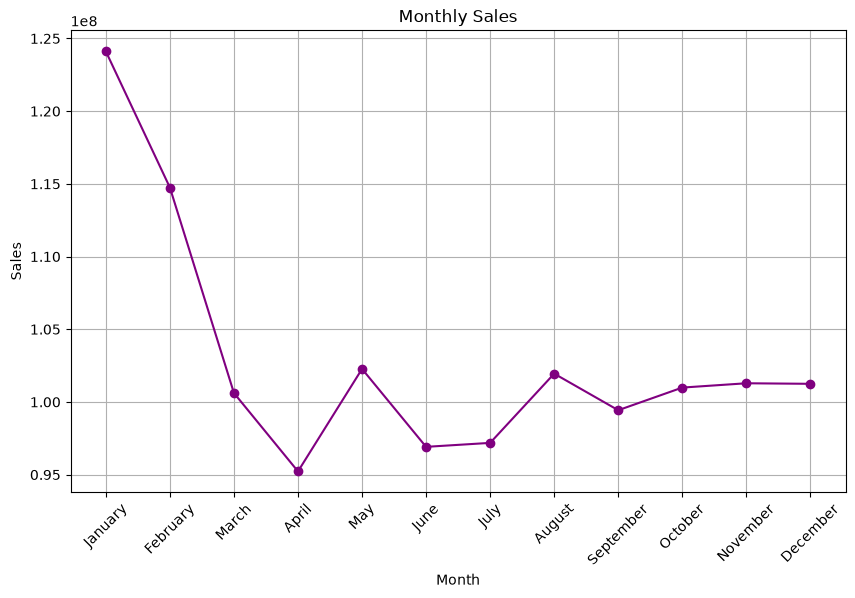

In [21]:

plt.figure(figsize=(10, 6))
plt.plot(
    overall_monthly_sales.index.astype(str), 
    overall_monthly_sales.values,
    color='purple', 
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**Note**: *Above graph is **not correct**. According to previous line chart, Feb has lowest sale but here Feb's sale is 2nd highest. It happening becausee of year 2018.*

In [22]:
monthly_sales
## we need  to ignore year 2018 to get perfect overall month sales

order_month
2014-01    25020272.3
2014-02    23882719.5
2014-03    23709035.4
2014-04    24853382.0
2014-05    25662165.8
2014-06    23818794.8
2014-07    23491988.9
2014-08    25408229.1
2014-09    25459497.5
2014-10    24259835.7
2014-11    26268221.0
2014-12    25686587.3
2015-01    25525914.6
2015-02    23027431.0
2015-03    24360945.4
2015-04    23744217.1
2015-05    24995904.4
2015-06    24528391.8
2015-07    24808203.9
2015-08    26155634.2
2015-09    24662586.1
2015-10    25466197.5
2015-11    25573136.2
2015-12    25562148.2
2016-01    24862829.0
2016-02    23151247.0
2016-03    26420512.0
2016-04    23179165.9
2016-05    25265324.8
2016-06    24804170.5
2016-07    24814997.7
2016-08    25082099.9
2016-09    24551560.4
2016-10    25896129.8
2016-11    25078997.8
2016-12    24976635.2
2017-01    24017201.9
2017-02    21241586.2
2017-03    26123159.3
2017-04    23447990.0
2017-05    26348721.5
2017-06    23761335.6
2017-07    24070011.3
2017-08    25301062.6
2017-09    24758657.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [24]:
df[~(df.order_date.dt.year == 2018)].tail()

,Unnamed: 0,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,unit_cost,...,county,state_name,region name,lat,budget,total_cost,profit,profit_margit_%,order_month,month_name
61621,61621,SO - 0003524,2017-12-31,Zooveo Company,Wholesale,Product 1,9,984.9,8864.1,512.148,...,Jackson County/Clay County,Missouri,Independence,39.08547,NaN,4609.332,4254.768,48.0,2017-12,December
61622,61622,SO - 0004785,2017-12-31,Wordware Company,Wholesale,Product 3,12,201.0,2412.0,90.450,...,Philadelphia County,Pennsylvania,Philadelphia,39.95234,NaN,1085.400,1326.600,55.0,2017-12,December
61623,61623,SO - 0004950,2017-12-31,Dynazzy Company,Distributor,Product 6,9,3825.7,34431.3,3098.817,...,Volusia County,Florida,Port Orange,29.13832,NaN,27889.353,6541.947,19.0,2017-12,December
61624,61624,SO - 0006829,2017-12-31,Pixoboo Corp,Distributor,Product 6,5,1835.8,9179.0,972.974,...,New Haven County,Connecticut,Milford,41.22509,NaN,4864.870,4314.130,47.0,2017-12,December
61625,61625,SO - 0009850,2017-12-31,Rooxo Company,Distributor,Product 26,8,207.7,1661.6,93.465,...,Madera County,California,Madera,36.96134,NaN,747.720,913.880,55.0,2017-12,December


In [25]:
overall_monthly_sales = df[~(df.order_date.dt.year == 2018)]\
    .groupby('month_name')['revenue']\
    .sum()\
    .reindex(month_sort)
overall_monthly_sales

month_name
January       99426217.8
February      91302983.7
March        100613652.1
April         95224755.0
May          102272116.5
June          96912692.7
July          97185201.8
August       101947025.8
September     99432301.4
October      100988872.2
November     101285199.8
December     101247927.7
Name: revenue, dtype: float64

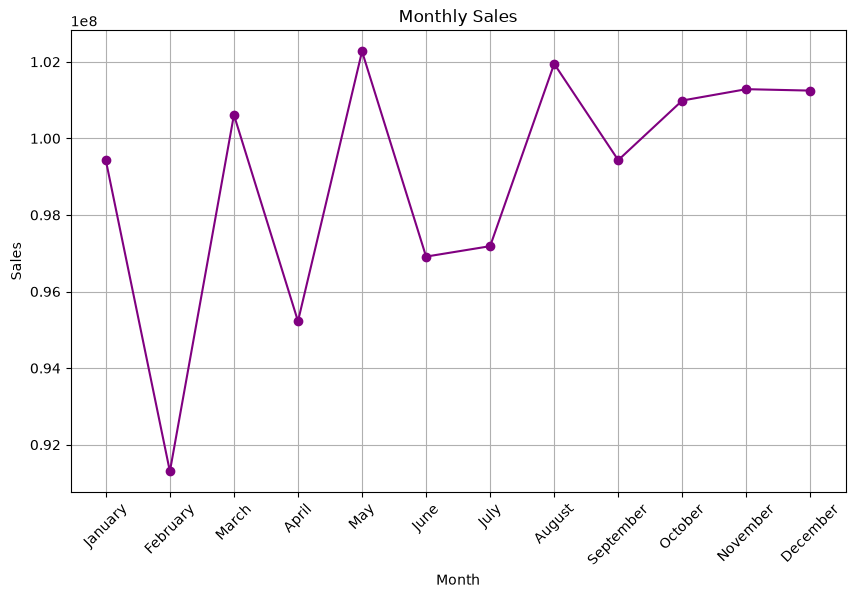

In [26]:
### overall monthly wise sales from 2014 to 2017
plt.figure(figsize=(10, 6))
plt.plot(
    overall_monthly_sales.index.astype(str), 
    overall_monthly_sales.values,
    color='purple', 
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

#### Bar chart of top product sales

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [28]:
top_products = df\
    .groupby('product_name')['revenue']\
    .sum()\
    .reset_index()\
    .sort_values(by=['revenue'],ascending=False)\
    .head(10)
top_products

,product_name,revenue
18,Product 26,117291821.4
17,Product 25,109473966.6
4,Product 13,78281379.6
5,Product 14,75390396.6
25,Product 5,70804380.6
6,Product 15,67331623.2
11,Product 2,57401097.6
24,Product 4,56701537.2
0,Product 1,55952289.6
22,Product 3,51764816.4


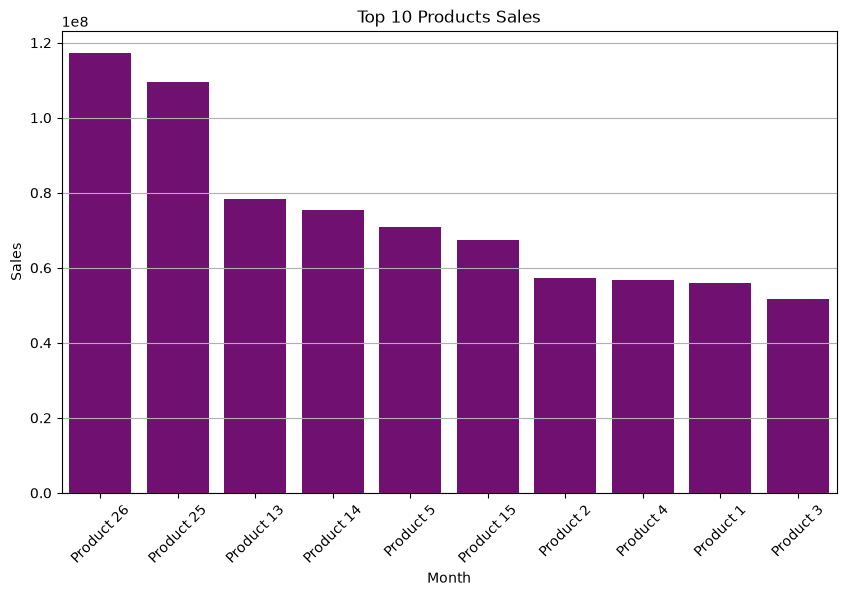

In [29]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    color='purple'
)
plt.title("Top 10 Products Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(
    visible=True,
    axis='y'
)

plt.show()

#### Bar chart of Low product sales

In [30]:
low_products = df\
    .groupby('product_name')['revenue']\
    .sum()\
    .reset_index()\
    .sort_values(by=['revenue'],ascending=True)\
    .head(15)\
    .sort_values(by=['revenue'],ascending=False)
low_products

,product_name,revenue
10,Product 19,34446174.0
3,Product 12,24173184.6
2,Product 11,22324426.8
20,Product 28,20823439.2
28,Product 8,19850679.6
13,Product 21,19246875.6
15,Product 23,18856855.2
23,Product 30,18590168.4
19,Product 27,18377791.8
1,Product 10,17660583.6


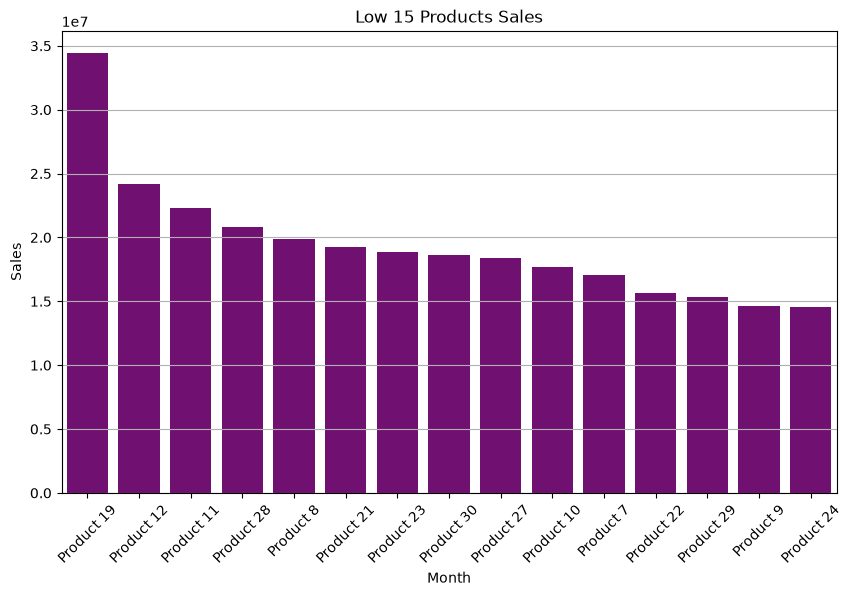

In [31]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(
    data=low_products,
    x='product_name',
    y='revenue',
    color='purple'
)
plt.title("Low 15 Products Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(
    visible=True,
    axis='y'
)

plt.show()

#### Sales by channel

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [33]:
chan_sales = df\
    .groupby('channel')['revenue']\
    .sum()\
    .reset_index()
chan_sales

,channel,revenue
0,Distributor,387139788.6
1,Export,180631866.0
2,Wholesale,668197244.4


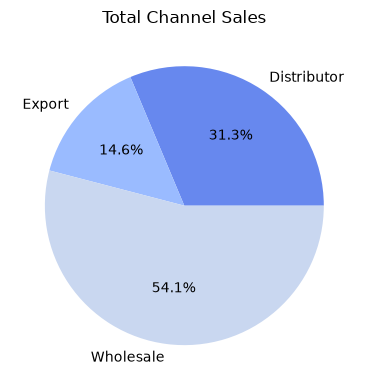

In [34]:
plt.figure(figsize=(4,4))
plt.pie(
    chan_sales.revenue,
    labels = chan_sales.channel,
    autopct = '%1.1f%%',
    colors = sns.color_palette('coolwarm')
)
plt.title('Total Channel Sales')
plt.tight_layout()
plt.show()

#### Order Value Distribution using histogram

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [36]:
df[df.order_number.duplicated()].sort_values(by=['order_number'])

,Unnamed: 0,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,unit_cost,...,county,state_name,region name,lat,budget,total_cost,profit,profit_margit_%,order_month,month_name
16019,16019,SO - 0001000,2015-01-13,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Hamilton County,Ohio,Colerain,39.25479,NaN,4438.080,1993.920,31.0,2015-01,January
17384,17384,SO - 0001000,2015-02-14,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Fresno County,California,Fresno,36.74773,NaN,4438.080,1993.920,31.0,2015-02,February
23283,23283,SO - 0001000,2015-07-06,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Essex County,New Jersey,Irvington,40.72386,NaN,4438.080,1993.920,31.0,2015-07,July
24471,24471,SO - 0001000,2015-08-03,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Orange County,California,Laguna Niguel,33.52253,NaN,4438.080,1993.920,31.0,2015-08,August
41003,41003,SO - 0001000,2016-08-27,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Union County,New Jersey,Elizabeth,40.66399,NaN,4438.080,1993.920,31.0,2016-08,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27435,27435,SO - 0010784,2015-10-11,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Providence County,Rhode Island,Cranston,41.77982,NaN,42072.382,15561.018,27.0,2015-10,October
31983,31983,SO - 0010784,2016-01-25,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Cook County,Illinois,Mount Prospect,42.06642,NaN,42072.382,15561.018,27.0,2016-01,January
47037,47037,SO - 0010784,2017-01-18,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Hartford County,Connecticut,West Hartford (CDP),41.76204,NaN,42072.382,15561.018,27.0,2017-01,January
51005,51005,SO - 0010784,2017-04-23,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Warren County,Kentucky,Bowling Green,36.99032,NaN,42072.382,15561.018,27.0,2017-04,April


In [37]:
df[df.order_number.duplicated()].sort_values(by=['order_number','order_date'])

,Unnamed: 0,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,unit_cost,...,county,state_name,region name,lat,budget,total_cost,profit,profit_margit_%,order_month,month_name
16019,16019,SO - 0001000,2015-01-13,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Hamilton County,Ohio,Colerain,39.25479,NaN,4438.080,1993.920,31.0,2015-01,January
17384,17384,SO - 0001000,2015-02-14,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Fresno County,California,Fresno,36.74773,NaN,4438.080,1993.920,31.0,2015-02,February
23283,23283,SO - 0001000,2015-07-06,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Essex County,New Jersey,Irvington,40.72386,NaN,4438.080,1993.920,31.0,2015-07,July
24471,24471,SO - 0001000,2015-08-03,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Orange County,California,Laguna Niguel,33.52253,NaN,4438.080,1993.920,31.0,2015-08,August
41003,41003,SO - 0001000,2016-08-27,Skyvu Group,Wholesale,Product 29,5,1286.4,6432.0,887.616,...,Union County,New Jersey,Elizabeth,40.66399,NaN,4438.080,1993.920,31.0,2016-08,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27435,27435,SO - 0010784,2015-10-11,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Providence County,Rhode Island,Cranston,41.77982,NaN,42072.382,15561.018,27.0,2015-10,October
31983,31983,SO - 0010784,2016-01-25,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Cook County,Illinois,Mount Prospect,42.06642,NaN,42072.382,15561.018,27.0,2016-01,January
47037,47037,SO - 0010784,2017-01-18,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Hartford County,Connecticut,West Hartford (CDP),41.76204,NaN,42072.382,15561.018,27.0,2017-01,January
51005,51005,SO - 0010784,2017-04-23,Oba Company,Wholesale,Product 2,11,5239.4,57633.4,3824.762,...,Warren County,Kentucky,Bowling Green,36.99032,NaN,42072.382,15561.018,27.0,2017-04,April


**Note** : *Df has dupliate order no. which I doesn't understand.*

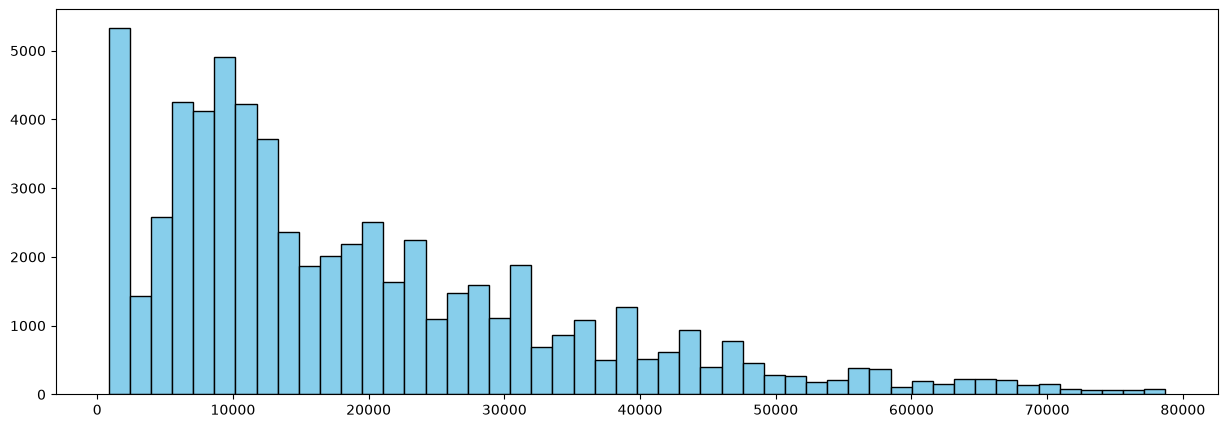

In [38]:
plt.figure(figsize=(15,5))
plt.hist(
    df.revenue,
    bins = 50,
    color = 'skyblue',
    edgecolor = 'black'
)
plt.show()

#### Unit Price Distribution per Product

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [41]:
df.product_name.unique()

<ArrowStringArray>
['Product 27', 'Product 20', 'Product 26',  'Product 7',  'Product 8',
 'Product 23',  'Product 1', 'Product 25', 'Product 13', 'Product 14',
  'Product 4', 'Product 15',  'Product 3', 'Product 10', 'Product 11',
  'Product 5', 'Product 16', 'Product 19',  'Product 2', 'Product 30',
 'Product 18', 'Product 17', 'Product 21', 'Product 12', 'Product 28',
 'Product 22',  'Product 6', 'Product 29', 'Product 24',  'Product 9']
Length: 30, dtype: str

In [61]:
product_price_dis = df\
    .iloc[:,[5,7]]
product_price_dis.head()

,product_name,unit_price
0,Product 27,2499.1
1,Product 20,2351.7
2,Product 26,978.2
3,Product 7,2338.3
4,Product 8,2291.4


In [64]:
# sort by product name and product no.
product_price_dis['product_no'] = product_price_dis\
    .product_name\
    .str.replace('[^0-9]','',regex=True)\
    .astype(int)
product_price_dis = product_price_dis.sort_values(by=['product_no'])
product_price_dis

,product_name,unit_price,product_no
62834,Product 1,1011.7,1
41648,Product 1,5366.7,1
62826,Product 1,1306.5,1
62824,Product 1,1969.8,1
23686,Product 1,1005.0,1
...,...,...,...
4722,Product 30,1996.6,30
4702,Product 30,180.9,30
4626,Product 30,830.8,30
27,Product 30,5681.6,30


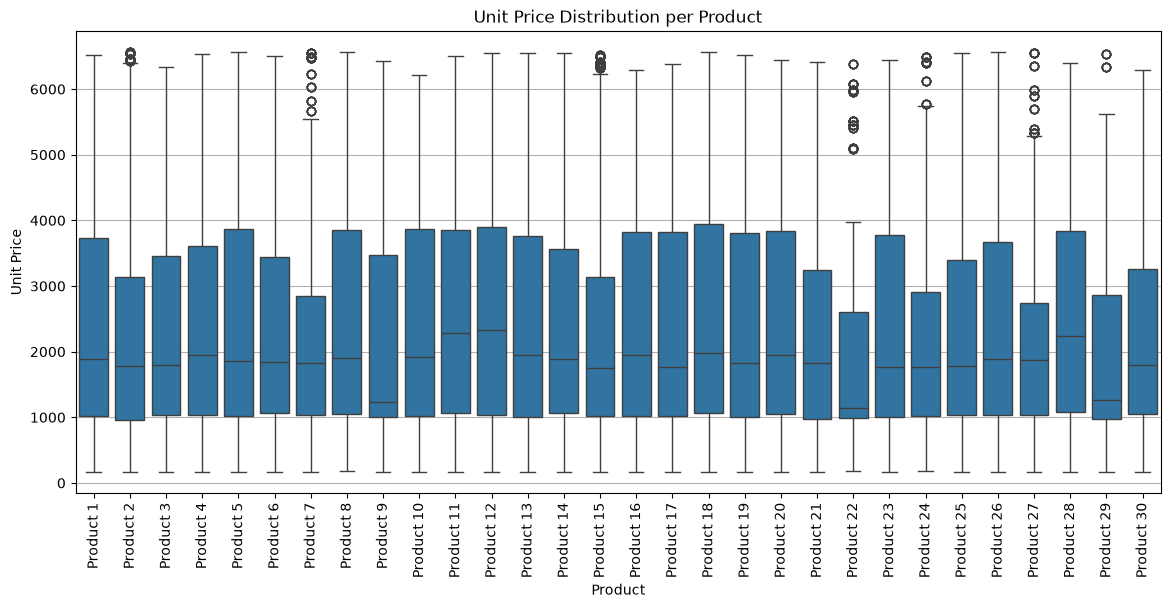

In [66]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=product_price_dis,
    x='product_name',
    y='unit_price'
)

plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price')
plt.xticks(rotation=90)
plt.grid(True, axis='y')

plt.show()

#### Top 10 States by Revenue and Order Count

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [76]:
top_states = df.groupby('state_name')['revenue']\
    .agg(['sum','count'])\
    .reset_index()\
    .sort_values(by='sum',ascending=False)\
    .head(10)
top_states

,state_name,sum,count
3,California,228785436.0,12000
11,Illinois,111050965.7,5682
8,Florida,90204679.5,4601
41,Texas,84011903.0,4289
30,New York,55534960.0,2829
12,Indiana,54601690.2,2830
28,New Jersey,46830956.5,2378
5,Connecticut,44251228.7,2264
20,Michigan,39025315.8,2039
19,Massachusetts,35011942.1,1768


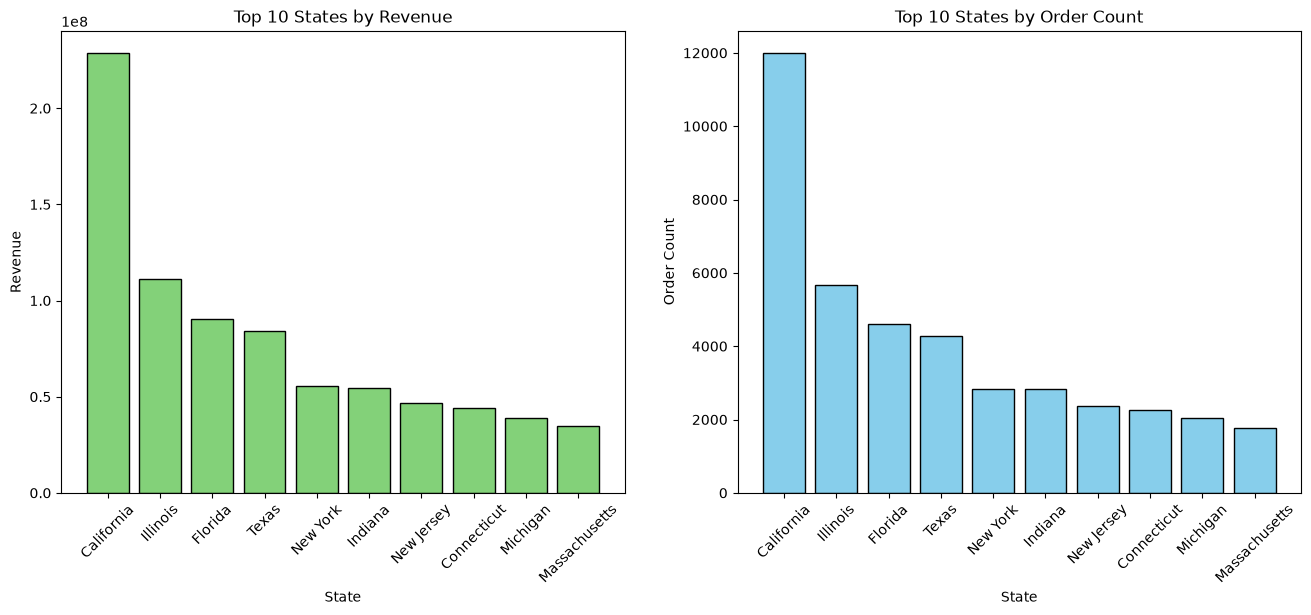

In [95]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)

plt.bar(
    top_states.state_name,
    top_states['sum'],
    color='#83D179',
    edgecolor='black'
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(
    top_states.state_name,
    top_states['count'],
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 10 States by Order Count')
plt.xlabel('State')
plt.ylabel('Order Count')
plt.xticks(rotation=45)

plt.show()

#### Avg Profit Margin by Channe

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [97]:
df.channel.unique()

<ArrowStringArray>
['Wholesale', 'Distributor', 'Export']
Length: 3, dtype: str

In [98]:
avg_profit_margin = (
    df.groupby('channel')['profit_margit_%']
      .mean()
      .sort_values(ascending=False)
)

avg_profit_margin

channel
Export         37.932704
Distributor    37.557091
Wholesale      37.087236
Name: profit_margit_%, dtype: float64

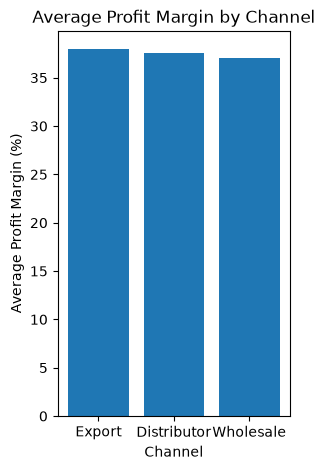

In [100]:
plt.figure(figsize=(3, 5))

plt.bar(
    avg_profit_margin.index,
    avg_profit_margin.values
)

plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Profit Margin (%)')

plt.show()

#### Top & Bottom 10 customers by revenue

In [101]:
customer_revenue = (
    df.groupby('customer_name')['revenue']
      .sum()
      .reset_index()
)

top_customers = (
    customer_revenue
    .sort_values(by='revenue', ascending=False)
    .head(10)
)

bottom_customers = (
    customer_revenue
    .sort_values(by='revenue', ascending=True)
    .head(10)
)

In [102]:
top_customers

,customer_name,revenue
4,Aibox Company,12641251.8
131,State Ltd,12220639.2
101,Pixoboo Corp,10986459.0
97,Organon Corp,10955826.6
106,Realbuzz Ltd,10753299.0
156,WOCKHARDT Group,10701963.6
72,Kare Corp,10635633.6
39,Colgate-Pa Group,10107003.6
63,Golden Corp,10007669.4
41,Deseret Group,9942223.8


In [103]:
bottom_customers

,customer_name,revenue
17,BB17 Company,4034673.0
163,Yodoo Ltd,4372755.0
84,Mycone Ltd,4534238.4
155,Voonyx Group,4670918.4
117,SEINDNI Corp,4760162.4
49,Epic Group,4807960.2
103,Quaxo Ltd,5026206.0
16,Aveda Group,5037100.2
167,Zoomdog Corp,5047914.0
71,Johnson Ltd,5083410.6


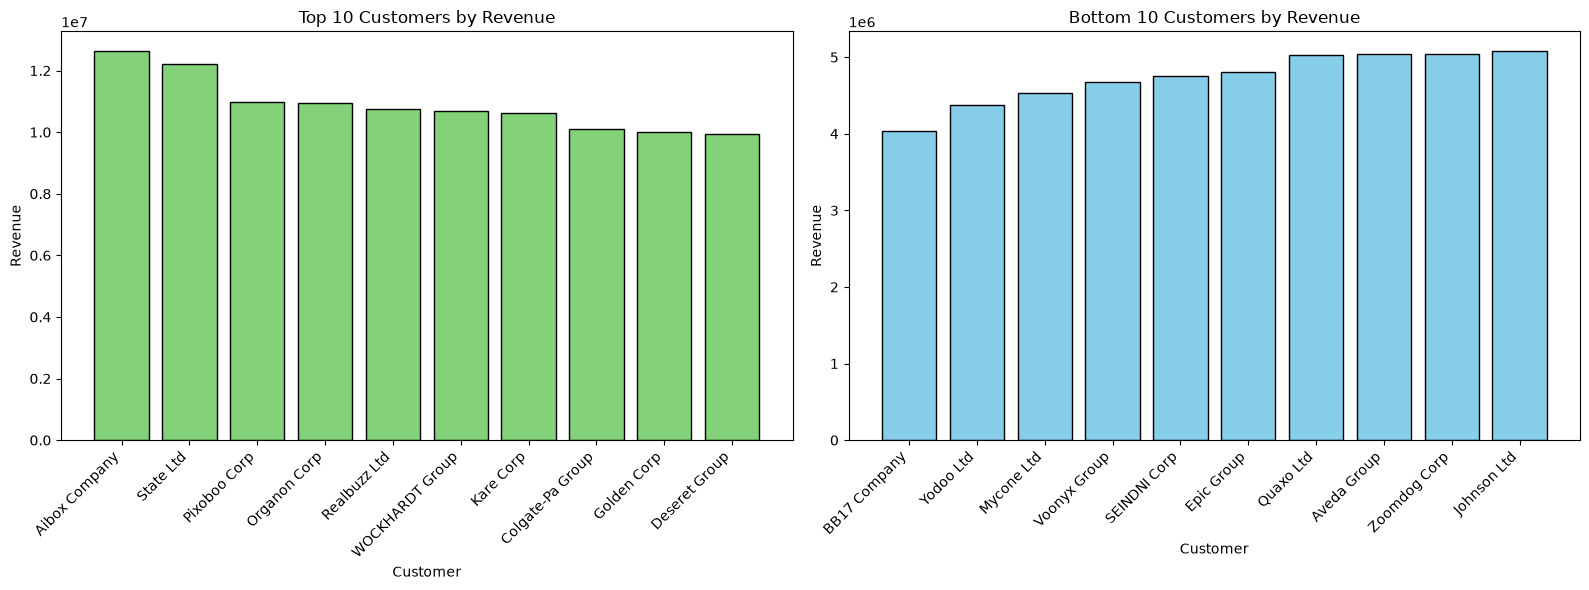

In [104]:
plt.figure(figsize=(16, 6))

# Top 10
plt.subplot(1, 2, 1)

plt.bar(
    top_customers['customer_name'],
    top_customers['revenue'],
    color='#83D179',
    edgecolor='black'
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')


# Bottom 10
plt.subplot(1, 2, 2)

plt.bar(
    bottom_customers['customer_name'],
    bottom_customers['revenue'],
    color='skyblue',
    edgecolor='black'
)

plt.title('Bottom 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Customer Segmentation: Revenue vs Profit Margin

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [107]:
df.groupby('customer_name')\
      .agg(
          revenue=('revenue', 'sum'),
          profit_margin=('profit_margit_%', 'mean')
      )\
      .reset_index()

,customer_name,revenue,profit_margin
0,ALK-Abello Ltd,7662321.0,38.223881
1,Accord Group,7116927.6,37.945455
2,Accudial Company,5835994.8,36.983607
3,Actavis Company,7074074.4,38.761905
4,Aibox Company,12641251.8,37.860465
...,...,...,...
170,Zoonoodle Ltd,6394855.2,39.475410
171,Zooveo Company,7175619.6,37.630769
172,Zoovu Corp,5682109.2,34.576923
173,Zooxo Ltd,6287842.8,36.950820


In [108]:
customer_segmentation = (
    df.groupby('customer_name')
      .agg(
          revenue=('revenue', 'sum'),
          profit_margin=('profit_margit_%', 'mean')
      )
      .reset_index()
)

customer_segmentation

,customer_name,revenue,profit_margin
0,ALK-Abello Ltd,7662321.0,38.223881
1,Accord Group,7116927.6,37.945455
2,Accudial Company,5835994.8,36.983607
3,Actavis Company,7074074.4,38.761905
4,Aibox Company,12641251.8,37.860465
...,...,...,...
170,Zoonoodle Ltd,6394855.2,39.475410
171,Zooveo Company,7175619.6,37.630769
172,Zoovu Corp,5682109.2,34.576923
173,Zooxo Ltd,6287842.8,36.950820


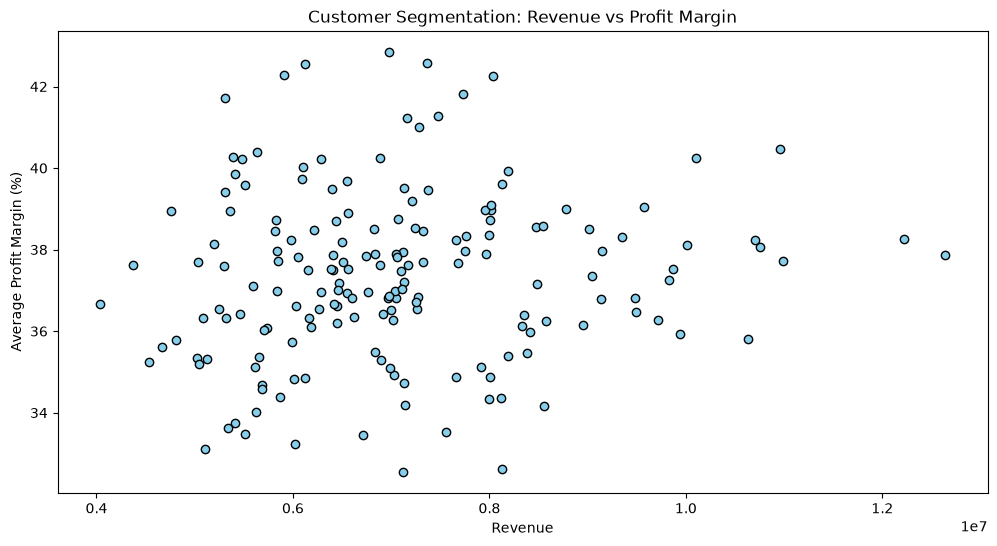

In [109]:
plt.figure(figsize=(12, 6))

plt.scatter(
    customer_segmentation['revenue'],
    customer_segmentation['profit_margin'],
    color='skyblue',
    edgecolor='black'
)

plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Revenue')
plt.ylabel('Average Profit Margin (%)')

plt.show()

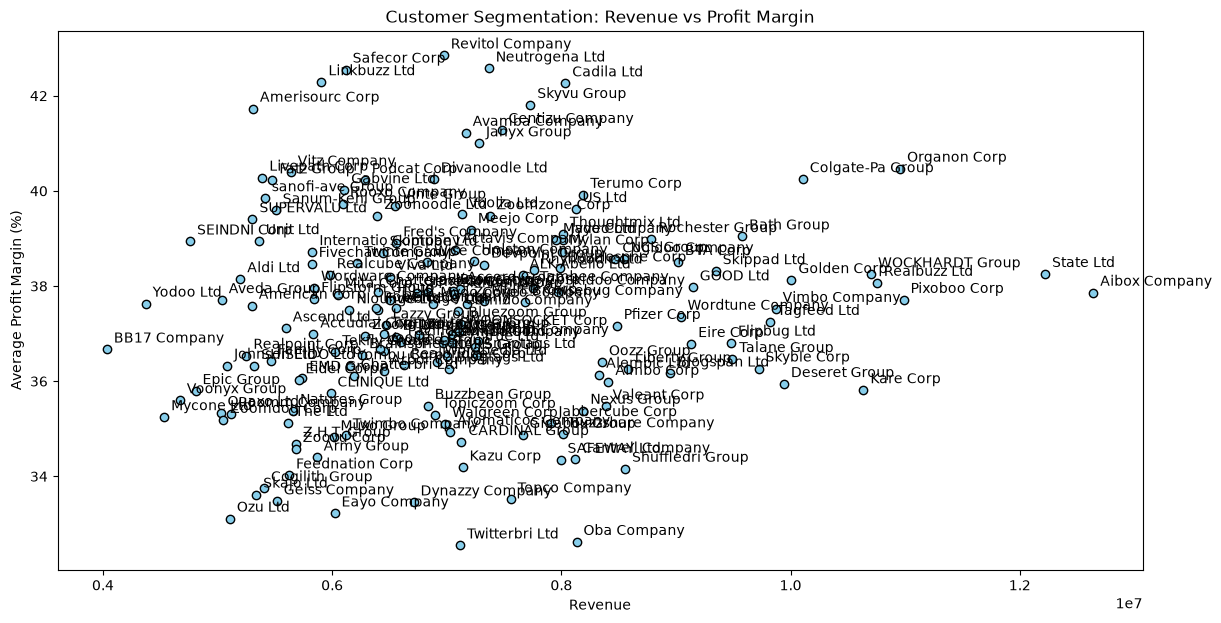

In [110]:
plt.figure(figsize=(14, 7))

plt.scatter(
    customer_segmentation['revenue'],
    customer_segmentation['profit_margin'],
    color='skyblue',
    edgecolor='black'
)

for i, row in customer_segmentation.iterrows():
    plt.annotate(
        row['customer_name'],
        (row['revenue'], row['profit_margin']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Revenue')
plt.ylabel('Average Profit Margin (%)')

plt.show()

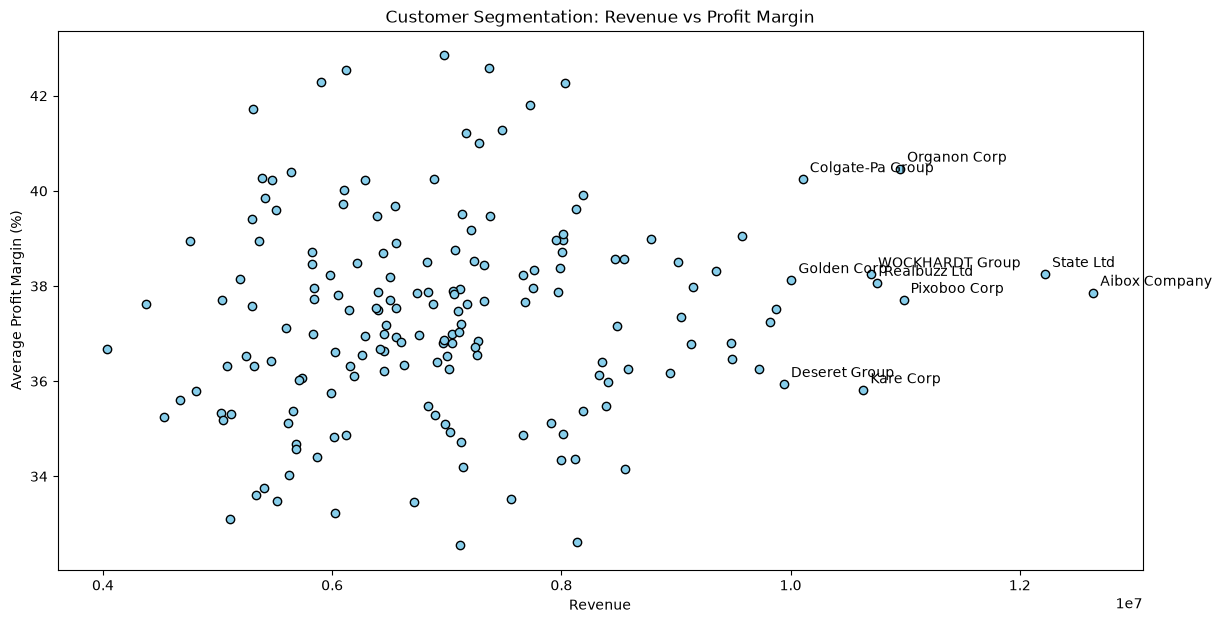

In [112]:
top_customers = customer_segmentation.sort_values(
    by='revenue',
    ascending=False
).head(10)

plt.figure(figsize=(14, 7))

plt.scatter(
    customer_segmentation['revenue'],
    customer_segmentation['profit_margin'],
    color='skyblue',
    edgecolor='black'
)

for i, row in top_customers.iterrows():
    plt.annotate(
        row['customer_name'],
        (row['revenue'], row['profit_margin']),
        xytext=(5, 5),
        textcoords='offset points'
    )
    
plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Revenue')
plt.ylabel('Average Profit Margin (%)')

plt.show()

#### Customer Segmentation: Revenue vs Profit Margin